## Mooring Report, Lake Zug, 2026.01.28

LZN mooring retrieval.

In [70]:
# imports
import ewgreaders as ewg
import pylake
import os
from glob import glob
import json
import xarray as xr
import numpy as np
import pandas as pd
import scipy
import dolfyn as dlfn
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [71]:
lake = 'Zugersee'
location = 'LZN'
year = '2026'
date = '20260318'

In [72]:
mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

### ADCP

In [73]:
adcp = adcps[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)

In [74]:
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260318/LZN/L0\3U420000.000 ...


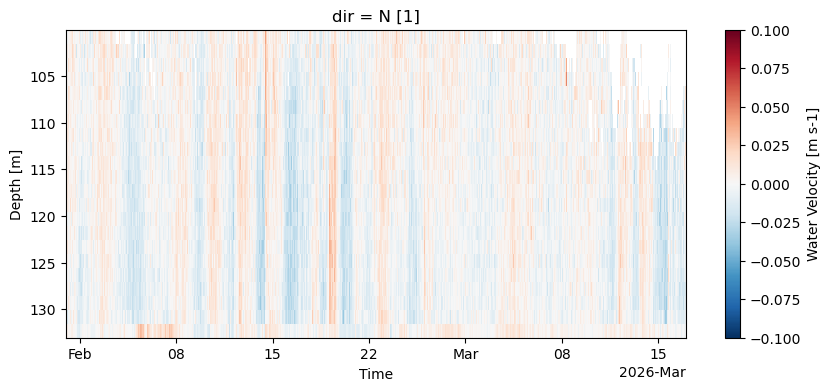

In [68]:
fig, ax = plt.subplots(figsize=(10, 4))

ds.vel.sel(dir='N').plot(cmap='RdBu_r', vmin=-0.1, vmax=0.1, ax=ax)

ax.set_xlabel('Time')
ax.set_ylabel('Depth [m]')
ax.invert_yaxis()
plt.show()

### Oxygen loggers

In [57]:
oxygen_loggers

[{'instrument': 'minidot', 'serial_id': '111103', 'mab': 63.6, 'comments': ''},
 {'instrument': 'minidot', 'serial_id': '107524', 'mab': 53, 'comments': ''},
 {'instrument': 'minidot', 'serial_id': '005932', 'mab': 42.4, 'comments': ''},
 {'instrument': 'minidot', 'serial_id': '164490', 'mab': 31.8, 'comments': ''},
 {'instrument': 'minidot', 'serial_id': '033587', 'mab': 26.5, 'comments': ''},
 {'instrument': 'minidot', 'serial_id': '000867', 'mab': 21.2, 'comments': ''},
 {'instrument': 'minidot', 'serial_id': '023560', 'mab': 15.9, 'comments': ''},
 {'instrument': 'minidot', 'serial_id': '917554', 'mab': 10.6, 'comments': ''}]

In [61]:
ds_chain = []
for ol in oxygen_loggers:
    serial_id = ol['serial_id']

    oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
    ds = oreader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


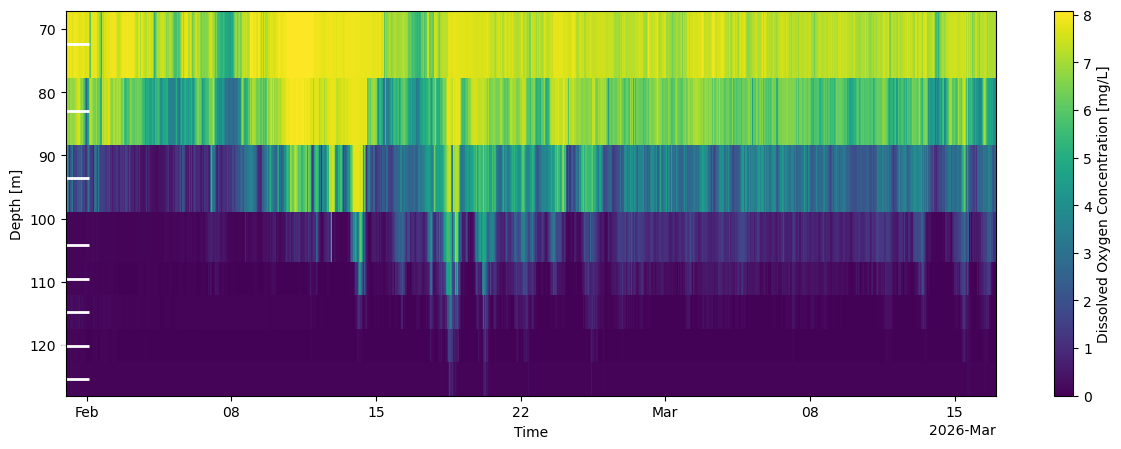

In [63]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, ax=ax)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Dissolved Oxygen Concentration [mg/L]")

ax.invert_yaxis()
plt.show()

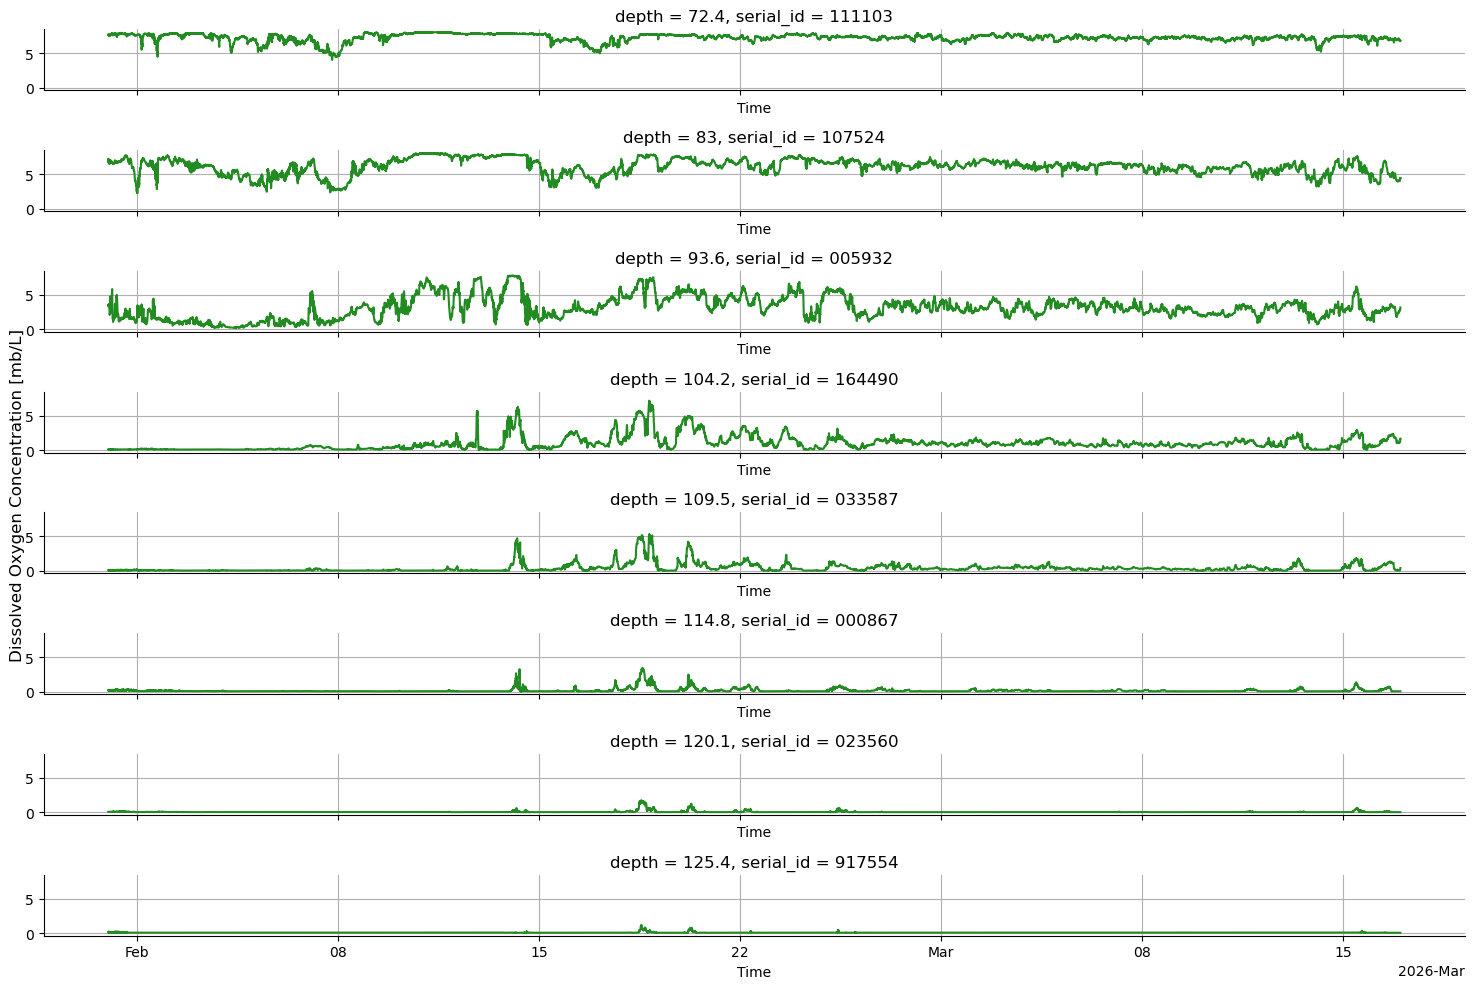

In [50]:
fig, ax = plt.subplots(nrows=len(ds_chain), ncols=1, figsize=(15, 10), sharex=True, sharey=True)

for i, d in enumerate(ds_chain):
    d['d_oxygen_conc'].plot(color='forestgreen', ax=ax[i])

    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('')

    ax[i].grid(True)
    ax[i].spines[['right', 'top']].set_visible(False)

fig.supylabel('Dissolved Oxygen Concentration [mb/L]')
plt.tight_layout()
plt.show()

### Thermistors

In [52]:
ds_chain = []
for t in thermistors:
    treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
    ds = treader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


In [64]:
ds_temp

<xarray.Dataset> Size: 56MB
Dimensions:    (depth: 17, time: 388801)
Coordinates:
  * time       (time) datetime64[ms] 3MB 2026-01-31 ... 2026-03-17
  * depth      (depth) float64 136B 45.9 51.2 56.5 61.8 ... 120.1 125.4 130.4
    serial_id  (depth) <U6 408B '205537' '205515' '205533' ... '209290' '205520'
Data variables:
    temp       (depth, time) float64 53MB 5.536 5.536 5.537 ... 5.455 5.455

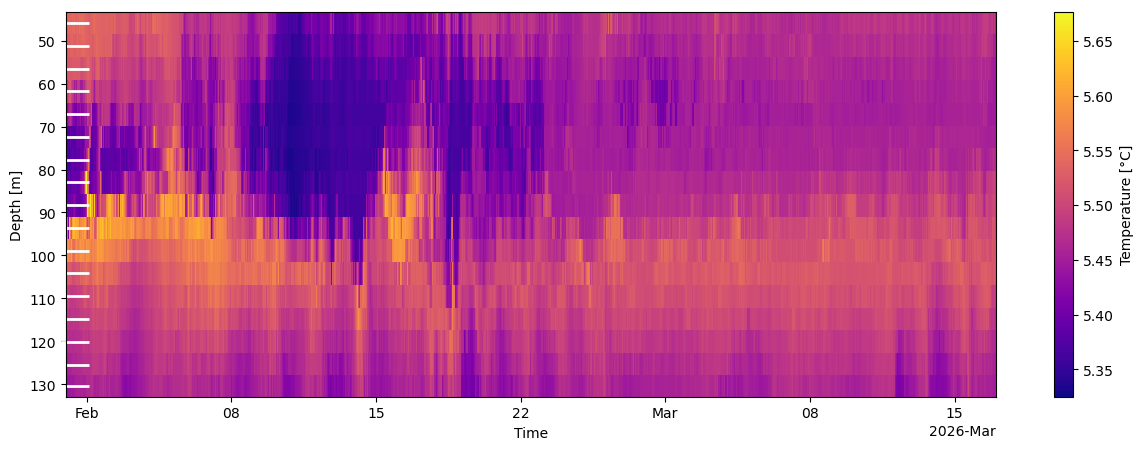

In [55]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_temp.temp.plot(cmap='plasma', ax=ax)
for d in ds_temp.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Temperature [°C]")

ax.invert_yaxis()
plt.show()

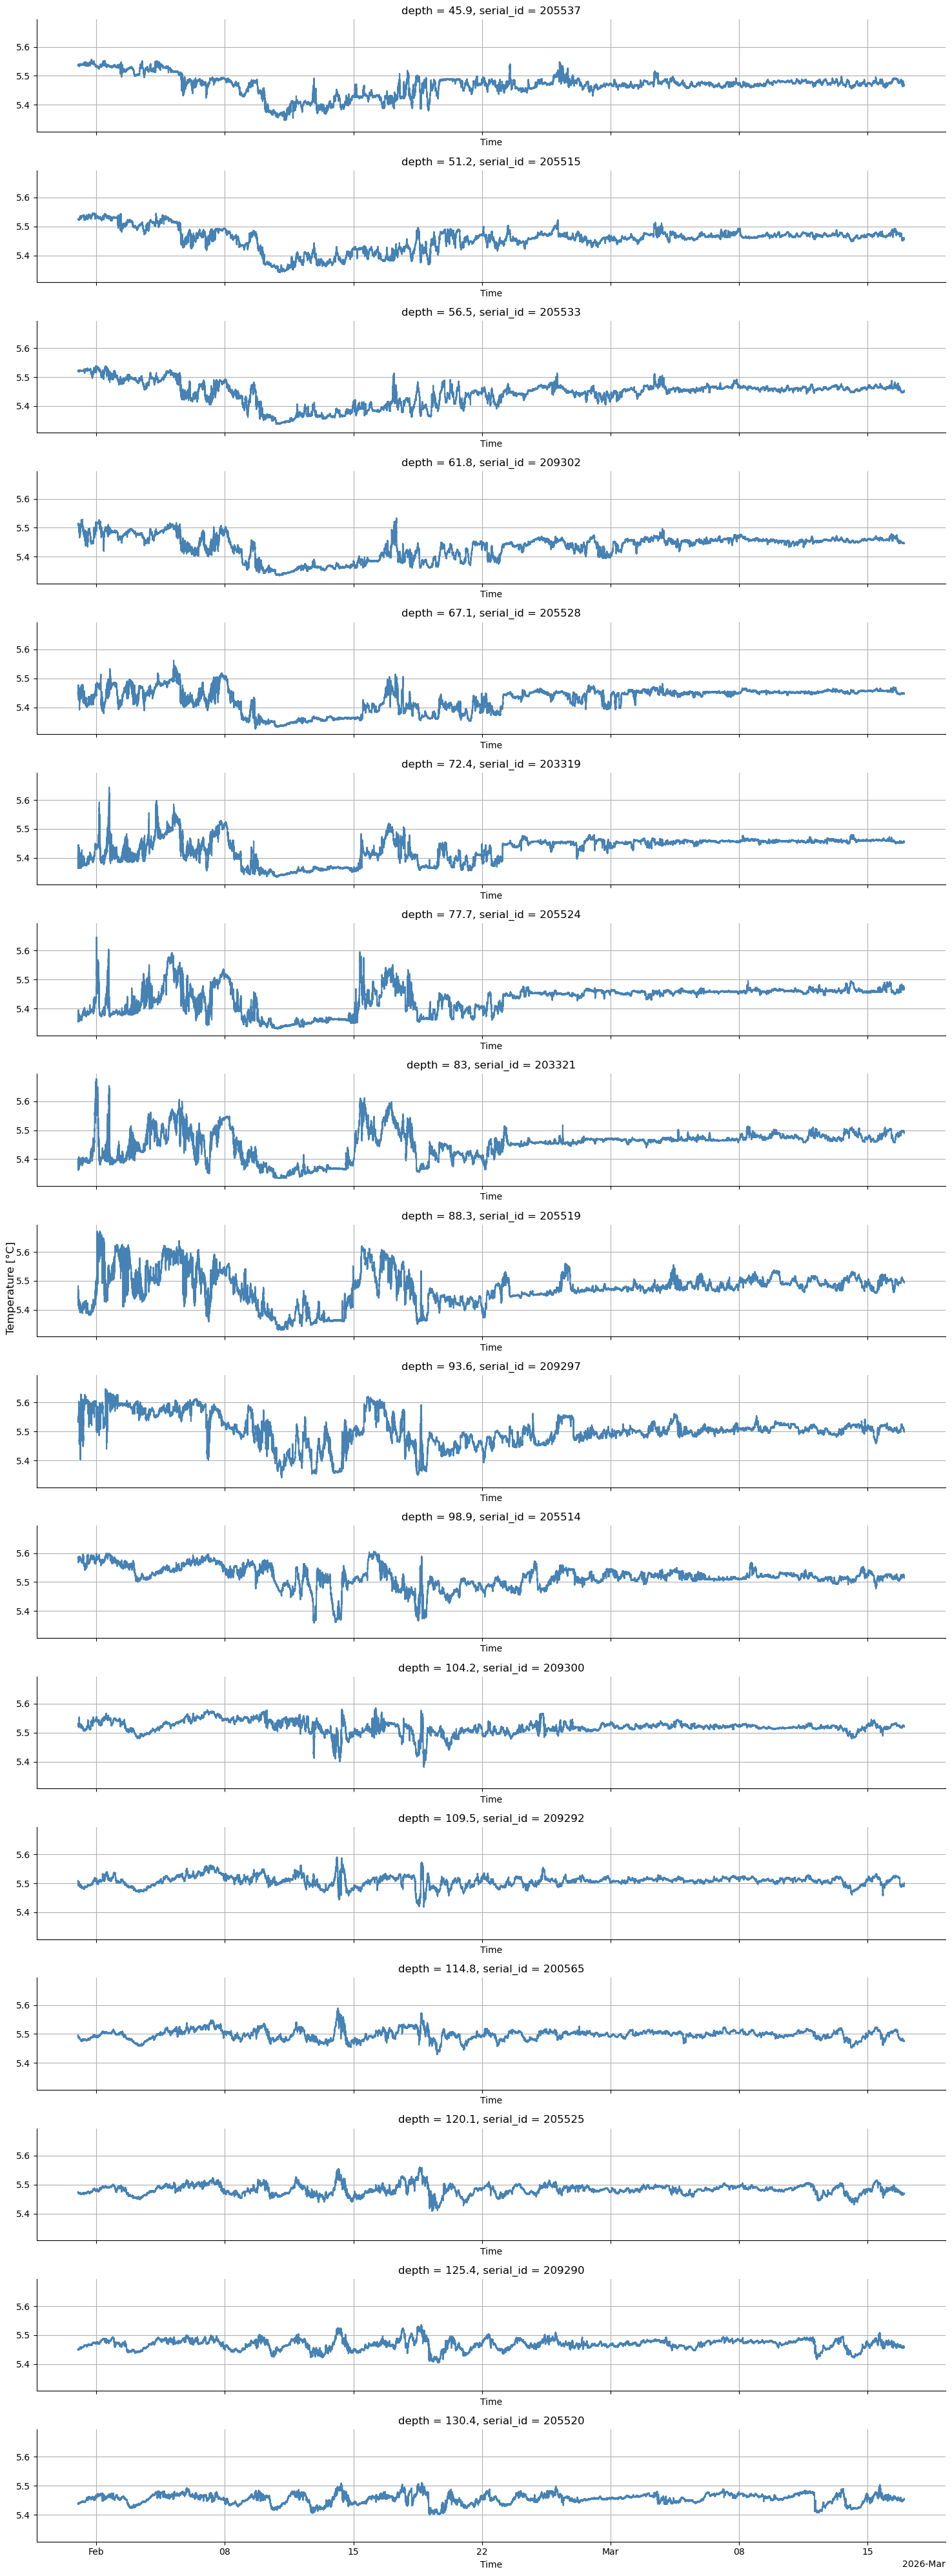

In [56]:
fig, ax = plt.subplots(nrows=len(ds_chain), ncols=1, figsize=(15, 40), sharex=True, sharey=True)

for i, d in enumerate(ds_chain):
    d['temp'].plot(color='steelblue', ax=ax[i])
    #ax[i].axhline(0, color='black', ls='--')

    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('')

    ax[i].grid(True)
    ax[i].spines[['right', 'top']].set_visible(False)

fig.supylabel('Temperature [°C]')
plt.tight_layout()
plt.show()